In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
class MLP:
    def __init__(self,input_dim,hidden_dim,out_dim=1):
        self.input_dim=input_dim
        self.hidden_dim=hidden_dim
        self.out_dim=out_dim

        self.w1=np.random.rand(input_dim,hidden_dim)*np.sqrt(2/input_dim)
        self.b1=np.zeros((1,hidden_dim))
        self.w2=np.random.randn(hidden_dim,out_dim)*np.sqrt(2/hidden_dim)
        self.b2=np.zeros((1,out_dim))

    def sigmoid(self,z):
        clip_z=np.clip(z,-500,500)
        return 1/(1+np.exp(-clip_z))
        
    def forward(self,x):
        self.X=x
        self.z1=np.dot(self.X,self.w1)+self.b1
        self.a1=self.sigmoid(self.z1)
        self.z2=np.dot(self.a1,self.w2)+self.b2
        self.a2=self.sigmoid(self.z2)

        return self.a2

    def compute_loss(self,y_hat,y):
        N=y.shape[0]
        eps=1e-15
        loss=-(1.0/N)*np.sum(y*np.log(y_hat+eps)+(1.0-y)*np.log(1.0-y_hat+eps))
        return loss

    def backward(self,y):
        n=y.shape[0]
        dz2=self.a2-y
        dw2=np.dot(self.a1.T,dz2)/n
        db2=np.sum(dz2,axis=0,keepdims=True)/n

        da1=np.dot(dz2,self.w2.T)
        dz1=da1* self.a1 *(1.0-self.a1)
        dw1=np.dot(self.X.T,dz1)/n
        db1=np.sum(dz1,axis=0,keepdims=True)/n

        self.grades={
        'w1':dw1,'b1':db1,
        'w2':dw2,'b2':db2
        }
        return self.grades

    def get_perams_vector(self):
        return np.concatenate([
            self.w1.ravel(),self.b1.ravel(),
            self.w2.ravel(),self.b2.ravel()
        ])

    def set_perams_from_vector(self,theta):
        w1_end=self.input_dim*self.hidden_dim
        b1_end=w1_end+self.hidden_dim
        w2_end=b1_end+(self.hidden_dim*self.out_dim)

        self.w1=theta[:w1_end].reshape(self.input_dim,self.hidden_dim)
        self.b1=theta[w1_end:b1_end].reshape((1,self.hidden_dim))
        self.w2=theta[b1_end:w2_end].reshape(self.hidden_dim,self.out_dim)
        self.b2=theta[w2_end:].reshape((1,self.out_dim))

    def set_grads_vecter(self):
        return np.concatenate([
            self.grades['w1'].ravel(),self.grades['b1'].ravel(),
            self.grades['w2'].ravel(),self.grades['b2'].ravel()
        ])
    

In [3]:
class SGD:
    def __init__(self,model,lr=0.01):
        self.model=model
        self.lr=lr

    def step(self):
        self.model.w1-=self.lr*self.model.grades['w1']
        self.model.b1-=self.lr*self.model.grades['b1']
        self.model.w2-=self.lr*self.model.grades['w2']
        self.model.b2-=self.lr*self.model.grades['b2']
        

In [4]:
class RMSProp:
    def __init__(self,model,beta=0.9,lr=0.01,eps=1e-8):
        self.lr=lr
        self.beta=beta
        self.model=model
        self.eps=eps
        
        self.v_w1=np.zeros_like(model.w1)
        self.v_b1=np.zeros_like(model.b1)
        self.v_w2=np.zeros_like(model.w2)
        self.v_b2=np.zeros_like(model.b2)
    def step(self):
        self.v_w1=self.beta*self.v_w1+(1-self.beta)*(self.model.grades['w1']**2)
        self.v_b1=self.beta*self.v_b1+(1-self.beta)*(self.model.grades['b1']**2)
        self.v_w2=self.beta*self.v_w2+(1-self.beta)*(self.model.grades['w2']**2)
        self.v_b2=self.beta*self.v_b2+(1-self.beta)*(self.model.grades['b2']**2)

        self.model.grades['w1']-=self.lr*self.model.grades['w1']/(np.sqrt(self.v_w1)+self.eps)
        self.model.grades['b1']-=self.lr*self.model.grades['b1']/(np.sqrt(self.v_b1)+self.eps)
        self.model.grades['w2']-=self.lr*self.model.grades['w2']/(np.sqrt(self.v_w2)+self.eps)
        self.model.grades['b2']-=self.lr*self.model.grades['b2']/(np.sqrt(self.v_b2)+self.eps)
        

In [5]:
class GradientsChecker:
    @staticmethod
    def check(model,x,y,eps=1e-7):
        orignal_theta=model.get_perams_vector()
        
        _=model.forward(x)
        ana_grades=model.backward(y)
        d_theta_ana=model.set_grads_vecter()

        num_perams=orignal_theta.shape[0]
        d_theta_num=np.zeros_like(orignal_theta)

        def evaluate_loss(theta_vec):
            model.set_perams_from_vector(theta_vec)
            pred=model.forward(x)
            return model.compute_loss(pred,y)

        for i in range(num_perams):
            t_plus=np.copy(orignal_theta)
            t_plus[i]+=eps
            loss_plus=evaluate_loss(t_plus)

            t_minus=np.copy(orignal_theta)
            t_minus[i]-=eps
            loss_minus=evaluate_loss(t_minus)

            d_theta_num[i]=(loss_plus-loss_minus)/(2*eps)
            
        model.set_perams_from_vector(orignal_theta)
        nominator=np.linalg.norm(d_theta_num-d_theta_ana)
        denom=np.linalg.norm(d_theta_num)+np.linalg.norm(d_theta_ana)

        if denom==0:
            return 0.0
        diff=nominator/denom

        return diff
        
            

In [6]:

np.random.seed(42)

n_samples = 100

X = np.random.rand(n_samples, 2) * 10

y = (X[:, 0] + X[:, 1] > 10).astype(int)
y=y.reshape(-1,1)
print(X[:5])
print(y[:5])


[[3.74540119 9.50714306]
 [7.31993942 5.98658484]
 [1.5601864  1.5599452 ]
 [0.58083612 8.66176146]
 [6.01115012 7.08072578]]
[[1]
 [1]
 [0]
 [0]
 [1]]


In [7]:
model=MLP(input_dim=2,hidden_dim=4,out_dim=1)
optimizer=RMSProp(model)

In [9]:
print("======LAUNCHING GRADEINTS CHECCKING========")
losses=[]
diff=GradientsChecker.check(model,X,y)
print(f"Relative Difference is :{diff}")
if diff<1e-7:
    print("succes :Every thing is correct")
elif diff<1e-4:
    print("Wrong :Minor precision")
else:
    print("Fianal Error : Check your implementation line by line")
epochs=int(input("How many epochs you want to train your model :"))
for epoch in range(epochs):
    y_pred=model.forward(X)
    loss=model.compute_loss(y_pred,y)
    losses.append(loss)
    model.backward(y)
    optimizer.step()

    if epoch %100==0:
        print(f"epoch :{epoch}   | Loss :{loss}")


======LAUNCHING GRADEINTS CHECCKING========
Relative Difference is :2.1952891042878354e-09
succes :Every thing is correct


How many epochs you want to train your model : 1


epoch :0   | Loss :0.9969192333762666


In [10]:
data=pd.read_csv('Titanic-Dataset.csv')

In [11]:
data.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [13]:
data=data.drop(['PassengerId','Name','PassengerId','Ticket','Cabin'],axis=1)

In [14]:
data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [15]:
data['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [16]:
data['Embarked']=data['Embarked'].map({'S':1, 'C':2, 'Q':3})
data['Sex']=data["Sex"].map({'male':0,'female':1})
    

In [17]:
data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,1.0
1,1,1,1,38.0,1,0,71.2833,2.0
2,1,3,1,26.0,0,0,7.9250,1.0
3,1,1,1,35.0,1,0,53.1000,1.0
4,0,3,0,35.0,0,0,8.0500,1.0
...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,1.0
887,1,1,1,19.0,0,0,30.0000,1.0
888,0,3,1,NaN,1,2,23.4500,1.0
889,1,1,0,26.0,0,0,30.0000,2.0


In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    float64
dtypes: float64(3), int64(5)
memory usage: 55.8 KB


In [19]:
data.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [20]:
data.Age=data.Age.fillna(data.Age.mean())

In [21]:
data.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64

In [22]:
data.dropna(inplace=True)

In [30]:
data.to_csv('clean.csv',index=False)

In [23]:
data.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [24]:
x=data.drop('Survived',axis=1)
y=data['Survived'].to_numpy().reshape(-1,1)


In [25]:
x.shape

(889, 7)

In [26]:
y.shape

(889, 1)

In [27]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [28]:
input_dims=x_train.shape[1]
hidden_dim=4
out_dim=1

In [41]:
input_dims

7

In [42]:
new_model=MLP(input_dims,hidden_dim,out_dim)
ooptimizer=SGD(new_model,lr=0.01)

In [31]:
print("======LAUNCHING GRADEINTS CHECCKING========")
train_losses=[]
diff=GradientsChecker.check(new_model,x_train,y_train)
print(f"Relative Difference is :{diff}")
if diff<1e-7:
    print("succes :Every thing is correct")
elif diff<1e-4:
    print("Wrong :Minor precision")
else:
    print("Fianal Error : Check your implementation line by line")
epochs=int(input("How many epochs you want to train your model :"))
for epoch in range(epochs):
    y_pred=new_model.forward(x_train)
    loss=new_model.compute_loss(y_pred,y_train)
    train_losses.append(loss)
    new_model.backward(y_train)
    optimizer.step()

    if epoch %100==0:
        print(f"epoch :{epoch}   | Loss :{loss}")

======LAUNCHING GRADEINTS CHECCKING========


NameError: name 'new_model' is not defined

In [44]:
test_losses=[]
for epoch in range(len(x_test)):
    pred=new_model.forward(x_test)
    test_loss=new_model.compute_loss(pred,y_test)
    test_losses.append(test_loss)
    prediction=np.mean(pred>=0.5).astype(int)
    acc=np.mean(prediction==y_test)
    
    
    

0.38764044943820225


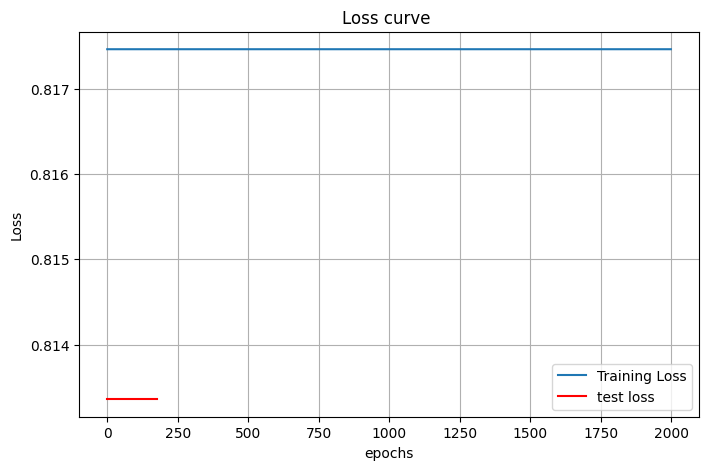

In [45]:
plt.figure(figsize=(8,5))
plt.plot(train_losses,label="Training Loss")
plt.plot(test_losses,label="test loss",c='r')
plt.xlabel("epochs")
plt.ylabel("Loss")
plt.title("Loss curve ")
plt.grid(True)
plt.legend()
plt.show()

In [53]:
model2=MLP(input_dims,hidden_dim=10,out_dim=out_dim)
optimizer1=RMSProp(model2,lr=0.1)

In [54]:
rms_tr_losses=[]
diff2=GradientsChecker.check(model2,x_train,y_train)
print(f"relative differnece is :{diff2}")
print('========================================')
if diff2<1e-7:
    print("Every thing is correct .")
elif diff2<1e-4:
    print("Wrong minor Error in precision.")
else:
    print("Full error check your implementation ")
print("==========================================")
for epoch in range(1000):
    pred=model2.forward(x_train)
    loss1=model2.compute_loss(pred,y_train)
    rms_tr_losses.append(loss1)
    model2.backward(y_train)
    optimizer1.step()

    if epoch %100==0:
        print(f"Epoch :{epoch} |loss :{loss:.6f}")

relative differnece is :3.205555944898218e-09
Every thing is correct .
Epoch :0 |loss :0.817461
Epoch :100 |loss :0.817461
Epoch :200 |loss :0.817461
Epoch :300 |loss :0.817461
Epoch :400 |loss :0.817461
Epoch :500 |loss :0.817461
Epoch :600 |loss :0.817461
Epoch :700 |loss :0.817461
Epoch :800 |loss :0.817461
Epoch :900 |loss :0.817461


In [57]:
test_rms_losses=[]
for epoch in range(len(x_test)):
    pred2=model2.forward(x_test)
    loss2=model2.compute_loss(pred2,y_test)
    test_rms_losses.append(loss2)
    prediction1=np.mean(pred>=0.5).astype(int)
    acc2=np.mean(prediction1==y_test)

    if epoch %100==0:
        print(f"Epoch {epoch}  | Loss {loss2}  |accuracy {acc2}")

Epoch 0  | Loss 0.8014864882230953  |accuracy 0.38764044943820225
Epoch 100  | Loss 0.8014864882230953  |accuracy 0.38764044943820225


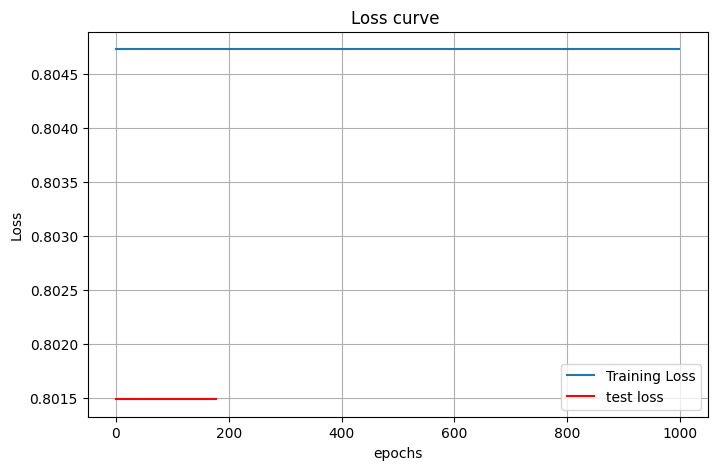

In [58]:
plt.figure(figsize=(8,5))
plt.plot(rms_tr_losses,label="Training Loss")
plt.plot(test_rms_losses,label="test loss",c='r')
plt.xlabel("epochs")
plt.ylabel("Loss")
plt.title("Loss curve ")
plt.grid(True)
plt.legend()
plt.show()

In [62]:
import MLP
import Optimizer
import Gradcheck


In [64]:
model3=MLP.MLP(7,10,1)
opim=Optimizer.RMSProp(model3,x_train,y_train)


In [70]:
rms_tr_losses1=[]
diff2=Gradcheck.GradientsChecker.check(model3,x_train,y_train)
print(f"relative differnece is :{diff2}")
print('========================================')
if diff2<1e-7:
    print("Every thing is correct .")
elif diff2<1e-4:
    print("Wrong minor Error in precision.")
else:
    print("Full error check your implementation ")
print("==========================================")
for epoch in range(1000):
    pred=model2.forward(x_train)
    loss1=model2.compute_loss(pred,y_train)
    rms_tr_losses1.append(loss1)
    model2.backward(y_train)
    optimizer1.step()

    if epoch %100==0:
        print(f"Epoch :{epoch} |loss :{loss:.6f}")

relative differnece is :3.233535786916689e-09
Every thing is correct .
Epoch :0 |loss :0.817461
Epoch :100 |loss :0.817461
Epoch :200 |loss :0.817461
Epoch :300 |loss :0.817461
Epoch :400 |loss :0.817461
Epoch :500 |loss :0.817461
Epoch :600 |loss :0.817461
Epoch :700 |loss :0.817461
Epoch :800 |loss :0.817461
Epoch :900 |loss :0.817461


In [71]:
len(rms_tr_losses1)

1000

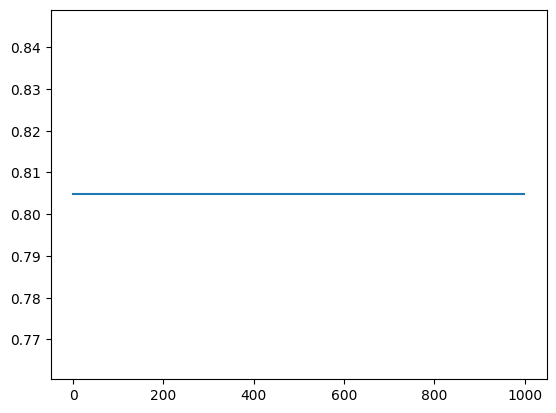

In [72]:
plt.plot(rms_tr_losses1)